In [1]:
import os
import torch
import torchvision
import torch.nn as nn
from torchvision import transforms
from torchvision.utils import save_image
from torch.autograd import Variable
import matplotlib.pyplot as plt
import pylab
import numpy as np
# %load_ext autoreload
# %autoreload 2

In [2]:
num_gpu = 1 if torch.cuda.is_available() else 0

# load the models
from dcgan import Discriminator, Generator

D = Discriminator(ngpu=1).eval()
G = Generator(ngpu=1).eval()

# load weights
D.load_state_dict(torch.load('out_animals/netD_epoch_87.pth'))
G.load_state_dict(torch.load('out_animals/netG_epoch_87.pth'))
if torch.cuda.is_available():
    D = D.cuda()
    G = G.cuda()

# generate some images

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

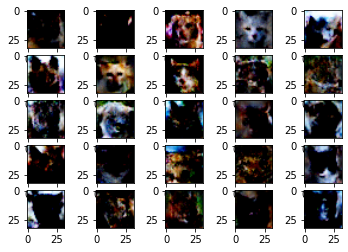

In [3]:
batch_size = 25
latent_size = 100

fixed_noise = torch.randn(batch_size, latent_size, 1, 1)
if torch.cuda.is_available():
    fixed_noise = fixed_noise.cuda()
fake_images = G(fixed_noise)


# z = torch.randn(batch_size, latent_size).cuda()
# z = Variable(z)
# fake_images = G(z)

fake_images_np = fake_images.cpu().detach().numpy()
fake_images_np = fake_images_np.reshape(fake_images_np.shape[0], 3, 32, 32)
fake_images_np = fake_images_np.transpose((0, 2, 3, 1))
R, C = 5, 5
for i in range(batch_size):
    plt.subplot(R, C, i + 1)
    plt.imshow(fake_images_np[i], interpolation='bilinear')
plt.show()

# run discriminator

In [4]:
outputs = D(fake_images)
print(outputs)

tensor([4.6405e-02, 3.4777e-01, 1.4920e-01, 5.7363e-02, 1.3703e-03, 5.4891e-01,
        1.8021e-01, 2.7282e-01, 1.7136e-01, 2.5941e-02, 1.2035e-01, 4.5278e-06,
        7.5290e-01, 2.9426e-02, 4.7908e-02, 6.1743e-07, 1.1470e-02, 5.5269e-02,
        4.7743e-02, 7.9653e-03, 1.5766e-01, 5.5970e-01, 4.4612e-01, 7.5853e-04,
        5.4390e-04], device='cuda:0', grad_fn=<SqueezeBackward1>)


In [6]:
fake_images_np[1].max()


0.854669

In [7]:
fake_images_np[1].min()

-0.73264897

In [35]:
start_noise = torch.randn(1, latent_size)
end_noise = torch.randn(1, latent_size)

delta = end_noise - start_noise
alpha = torch.linspace(0, 1, batch_size)
interpolated_noise = torch.cat([start_noise * ( 1 - i / batch_size) + end_noise * i / batch_size for i in range(batch_size)], dim=0)


fixed_noise = interpolated_noise.unsqueeze(2).unsqueeze(3)



In [36]:
fixed_noise.size()

torch.Size([25, 100, 1, 1])

In [37]:
if torch.cuda.is_available():
    fixed_noise = fixed_noise.cuda()
fake_images = G(fixed_noise)

fake_images_np = fake_images.cpu().detach().numpy()
fake_images_np = fake_images_np.reshape(fake_images_np.shape[0], 3, 32, 32)
fake_images_np = fake_images_np.transpose((0, 2, 3, 1))

fake_images_np = fake_images_np / 2 + 0.5

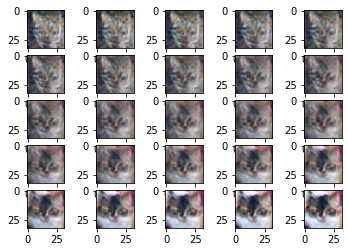

In [38]:
for i in range(batch_size):
    plt.subplot(R, C, i + 1)
    plt.imshow(fake_images_np[i], interpolation='bilinear')
plt.show()